# Полный пайплайн распознавания лиц

Пайплайн выполняет четыре этапа:

1. предобученный **MTCNN** обнаруживает все лица;
2. ваша **Stacked Hourglass** из задания 1 предсказывает пять ключевых точек;
3. лицо выравнивается по ключевым точкам;
4. ваша **ResNet18 + ArcFace** из задания 2 формирует L2-нормированный эмбеддинг.

Ноутбук также сравнивает одинаковых и разных людей, строит индекс датасета и позволяет загрузить собственную фотографию для поиска ближайшего лица.


## 1. Установка и импорты

In [1]:
# Выполните один раз, если пакеты не установлены.
#%pip install -q facenet-pytorch ipywidgets

In [2]:
from pathlib import Path
import io, os, json, warnings
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from facenet_pytorch import MTCNN

warnings.filterwarnings("ignore")
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", DEVICE)

Устройство: cuda


## 2. Конфигурация путей

In [3]:
PROCESSED_DIR=Path(r"D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new")
HOURGLASS_CHECKPOINT=PROCESSED_DIR/"models_hourglass"/"best_model.pth"
ARCFACE_CHECKPOINT=PROCESSED_DIR/"face_recognition_final"/"models"/"arcface_best.pth"
GALLERY_CSV=PROCESSED_DIR/"train_with_identity.csv"
GALLERY_IMAGE_DIR=PROCESSED_DIR/"aligned_faces_all"
GALLERY_INDEX_PATH=PROCESSED_DIR/"face_recognition_final"/"gallery_embeddings.npz"

HOURGLASS_INPUT_SIZE=(96,96)
HEATMAP_SIZE=(48,48)
FACE_SIZE=(128,128)
MIN_FACE_CONFIDENCE=0.90
GALLERY_LIMIT=None  # например 1000 для быстрого теста

for p in [HOURGLASS_CHECKPOINT,ARCFACE_CHECKPOINT,GALLERY_CSV,GALLERY_IMAGE_DIR]:
    print(p, "->", p.exists())

D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new\models_hourglass\best_model.pth -> True
D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new\face_recognition_final\models\arcface_best.pth -> True
D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new\train_with_identity.csv -> True
D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new\aligned_faces_all -> True


## 3. Stacked Hourglass из задания 1

In [4]:
class ResidualBlock(nn.Module):
    def __init__(self,in_channels,out_channels):
        super().__init__()
        self.skip=nn.Identity() if in_channels==out_channels else nn.Conv2d(in_channels,out_channels,1)
        self.conv1=nn.Conv2d(in_channels,out_channels//2,1); self.bn1=nn.BatchNorm2d(out_channels//2)
        self.conv2=nn.Conv2d(out_channels//2,out_channels//2,3,padding=1); self.bn2=nn.BatchNorm2d(out_channels//2)
        self.conv3=nn.Conv2d(out_channels//2,out_channels,1); self.bn3=nn.BatchNorm2d(out_channels)
        self.relu=nn.ReLU(inplace=True)
    def forward(self,x):
        residual=self.skip(x)
        x=self.relu(self.bn1(self.conv1(x)))
        x=self.relu(self.bn2(self.conv2(x)))
        x=self.bn3(self.conv3(x))
        return self.relu(x+residual)

class HourglassModule(nn.Module):
    def __init__(self,in_channels,mid_channels,out_channels,num_blocks=3):
        super().__init__(); self.num_blocks=num_blocks
        self.input_block=ResidualBlock(in_channels,mid_channels)
        self.down_blocks=nn.ModuleList(); self.down_samples=nn.ModuleList(); self.skip_blocks=nn.ModuleList()
        self.up_blocks=nn.ModuleList(); self.up_samples=nn.ModuleList()
        self.bottleneck=ResidualBlock(mid_channels,mid_channels)
        for _ in range(num_blocks):
            self.down_blocks.append(ResidualBlock(mid_channels,mid_channels))
            self.down_samples.append(nn.MaxPool2d(2))
            self.skip_blocks.append(ResidualBlock(mid_channels,mid_channels))
            self.up_blocks.append(ResidualBlock(mid_channels*2,mid_channels))
            self.up_samples.append(nn.Upsample(scale_factor=2,mode="nearest"))
        self.output_block=ResidualBlock(mid_channels,out_channels)
    def forward(self,x):
        x=self.input_block(x); skips=[]
        for i in range(self.num_blocks):
            x=self.down_blocks[i](x); skips.append(self.skip_blocks[i](x))
            if i<self.num_blocks-1: x=self.down_samples[i](x)
        x=self.bottleneck(x)
        for i in range(self.num_blocks-1,-1,-1):
            x=self.up_samples[i](x)
            if x.shape[2:]!=skips[i].shape[2:]: x=F.interpolate(x,size=skips[i].shape[2:],mode="nearest")
            x=self.up_blocks[i](torch.cat([x,skips[i]],dim=1))
        return self.output_block(x)

class StackedHourglass(nn.Module):
    def __init__(self,num_stacks=2,num_landmarks=5,mid_channels=64,hourglass_blocks=3,output_size=(48,48)):
        super().__init__(); self.num_stacks=num_stacks
        self.input_conv=nn.Sequential(nn.Conv2d(3,64,7,padding=3),nn.BatchNorm2d(64),nn.ReLU(inplace=True),ResidualBlock(64,mid_channels))
        self.hourglass_stacks=nn.ModuleList(); self.heads=nn.ModuleList(); self.intermediate_convs=nn.ModuleList()
        for i in range(num_stacks):
            self.hourglass_stacks.append(HourglassModule(mid_channels,mid_channels,mid_channels,hourglass_blocks))
            self.heads.append(nn.Sequential(nn.Conv2d(mid_channels,mid_channels,1),nn.BatchNorm2d(mid_channels),nn.ReLU(inplace=True),nn.Conv2d(mid_channels,num_landmarks,1),nn.Upsample(size=output_size,mode="bilinear",align_corners=False)))
            if i<num_stacks-1:
                self.intermediate_convs.append(nn.Sequential(nn.Conv2d(mid_channels+num_landmarks,mid_channels,1),nn.BatchNorm2d(mid_channels),nn.ReLU(inplace=True)))
    def forward(self,x):
        x=self.input_conv(x); outputs=[]
        for i in range(self.num_stacks):
            x=self.hourglass_stacks[i](x); hm=self.heads[i](x); outputs.append(hm)
            if i<self.num_stacks-1:
                x=self.intermediate_convs[i](torch.cat([x,F.interpolate(hm,size=x.shape[2:],mode="bilinear",align_corners=False)],dim=1))
        return outputs

## 4. ArcFace из задания 2

In [5]:
class ArcFaceLayer(nn.Module):
    def __init__(self,in_features,num_classes,s=30.0,m=0.50):
        super().__init__(); self.num_classes=num_classes; self.s=s; self.m=m
        self.cos_m=np.cos(m); self.sin_m=np.sin(m); self.th=np.cos(np.pi-m); self.mm=np.sin(np.pi-m)*m
        self.weight=nn.Parameter(torch.empty(num_classes,in_features)); nn.init.xavier_uniform_(self.weight)
    def forward(self,x,target):
        x=F.normalize(x,p=2,dim=1); w=F.normalize(self.weight,p=2,dim=1)
        cosine=F.linear(x,w); sine=torch.sqrt(torch.clamp(1-cosine.pow(2),min=0))
        phi=torch.where(cosine>self.th,cosine*self.cos_m-sine*self.sin_m,cosine-self.mm)
        one_hot=torch.zeros_like(cosine); one_hot.scatter_(1,target.view(-1,1).long(),1)
        return (one_hot*phi+(1-one_hot)*cosine)*self.s

class ArcFaceModel(nn.Module):
    def __init__(self,backbone,num_classes,embedding_size=128):
        super().__init__(); self.backbone=backbone
        in_features=backbone.fc.in_features; backbone.fc=nn.Linear(in_features,embedding_size)
        self.arcface=ArcFaceLayer(embedding_size,num_classes)
    def forward(self,x,labels=None):
        emb=self.backbone(x)
        if labels is not None: return self.arcface(emb,labels),emb
        return F.normalize(emb,p=2,dim=1)

## 5. Загрузка ваших моделей

In [6]:
def strip_module(state):
    return {k.removeprefix("module."):v for k,v in state.items()}

def load_hourglass(path):
    cp=torch.load(path,map_location=DEVICE,weights_only=False); state=strip_module(cp.get("model_state_dict",cp))
    model=StackedHourglass(num_stacks=int(cp.get("num_stacks",2)),mid_channels=int(cp.get("mid_channels",64)),hourglass_blocks=3,output_size=HEATMAP_SIZE).to(DEVICE)
    model.load_state_dict(state); model.eval(); return model

def load_arcface(path):
    cp=torch.load(path,map_location=DEVICE,weights_only=False); state=strip_module(cp.get("model_state_dict",cp))
    n_classes,emb_size=state["arcface.weight"].shape
    model=ArcFaceModel(models.resnet18(weights=None),n_classes,emb_size).to(DEVICE)
    model.load_state_dict(state); model.eval()
    print(f"ArcFace: {n_classes} классов, embedding={emb_size}, val_acc={cp.get('val_acc','нет')}")
    return model

hourglass_model=load_hourglass(HOURGLASS_CHECKPOINT)
arcface_model=load_arcface(ARCFACE_CHECKPOINT)
detector=MTCNN(keep_all=True,device=DEVICE,min_face_size=20,thresholds=[0.6,0.7,0.7],post_process=False)
print("Модели готовы")

ArcFace: 100 классов, embedding=128, val_acc=76.62337662337663
Модели готовы


## 6. Детекция, ключевые точки, выравнивание и эмбеддинг

In [9]:
arc_transform=transforms.Compose([transforms.ToPILImage(),transforms.Resize(FACE_SIZE),transforms.ToTensor(),transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
REFERENCE=np.array([[38.4,51.2],[89.6,51.2],[64.0,73.0],[45.0,96.0],[83.0,96.0]],dtype=np.float32)

def read_rgb(source):
    if isinstance(source,(str,Path)):
        bgr=cv2.imread(str(source))
        if bgr is None: raise FileNotFoundError(source)
        return cv2.cvtColor(bgr,cv2.COLOR_BGR2RGB)
    if isinstance(source,Image.Image): return np.asarray(source.convert("RGB"))
    if isinstance(source,np.ndarray): return source.astype(np.uint8)
    raise TypeError("Нужен путь, PIL.Image или numpy.ndarray")

def detect_faces(image):
    boxes,probs=detector.detect(Image.fromarray(image)); out=[]
    if boxes is None: return out
    h,w=image.shape[:2]
    for box,p in zip(boxes,probs):
        if float(p)<MIN_FACE_CONFIDENCE: continue
        x1,y1,x2,y2=box; bw=x2-x1; bh=y2-y1; m=.18
        x1=max(0,int(x1-bw*m)); y1=max(0,int(y1-bh*m)); x2=min(w,int(x2+bw*m)); y2=min(h,int(y2+bh*m))
        crop=image[y1:y2,x1:x2]
        if crop.size: out.append({"bbox":np.array([x1,y1,x2,y2]),"confidence":float(p),"crop":crop})
    return out

def predict_landmarks(crop):
    h,w=crop.shape[:2]; resized=cv2.resize(crop,HOURGLASS_INPUT_SIZE)
    x=torch.from_numpy(resized).permute(2,0,1).float().div(255).unsqueeze(0).to(DEVICE)
    with torch.inference_mode(): heatmaps=hourglass_model(x)[-1][0].cpu().numpy()
    pts=[]
    for hm in heatmaps:
        y,x=np.unravel_index(np.argmax(hm),hm.shape)
        pts.append([x/(hm.shape[1]-1)*w,y/(hm.shape[0]-1)*h])
    return np.asarray(pts,dtype=np.float32)

def align_face(crop,points):
    matrix,_=cv2.estimateAffinePartial2D(points,REFERENCE,method=cv2.LMEDS)
    if matrix is None: return cv2.resize(crop,FACE_SIZE)
    return cv2.warpAffine(crop,matrix,FACE_SIZE,borderMode=cv2.BORDER_CONSTANT,borderValue=(0,0,0))

def embedding_from_aligned(face):
    x=arc_transform(face).unsqueeze(0).to(DEVICE)
    with torch.inference_mode(): return arcface_model(x)[0].cpu().numpy().astype(np.float32)

def process_image(source,visualize=True):
    image=read_rgb(source); results=[]
    for i,d in enumerate(detect_faces(image)):
        pts=predict_landmarks(d["crop"]); aligned=align_face(d["crop"],pts); emb=embedding_from_aligned(aligned)
        results.append({"face_index":i,"bbox":d["bbox"],"confidence":d["confidence"],"landmarks":pts,"aligned_face":aligned,"embedding":emb})
    if visualize: show_results(image,results)
    return results

def show_results(image, results):
    if not results:
        print("Лица не найдены")
        plt.imshow(image)
        plt.axis("off")
        plt.show()
        return

    fig, axes = plt.subplots(
        1,
        len(results) + 1,
        figsize=(5 * (len(results) + 1), 5)
    )

    axes = np.atleast_1d(axes)

    # Исходное изображение
    axes[0].imshow(image)

    for result in results:
        x1, y1, x2, y2 = result["bbox"]

        rectangle = plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2
        )

        axes[0].add_patch(rectangle)

        axes[0].text(
            x1,
            y1,
            f"face {result['face_index']}: "
            f"{result['confidence']:.3f}",
            bbox={
                "facecolor": "white",
                "alpha": 0.7
            }
        )

    axes[0].axis("off")
    axes[0].set_title("Вход")

    # Выровненные лица
    for ax, result in zip(axes[1:], results):
        ax.imshow(result["aligned_face"])

        ax.set_title(
            f"Лицо {result['face_index']}\n"
            f"{len(result['embedding'])}D"
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

## 7. Обработка фотографии с несколькими лицами

In [10]:
INPUT_IMAGE_PATH=r"D:\path\to\photo_with_faces.jpg"
# results=process_image(INPUT_IMAGE_PATH)
# print("Найдено лиц:",len(results))
# print([r["embedding"].shape for r in results])

## 8. Метрики расстояния

In [11]:
def compare_embeddings(a,b):
    a=a/(np.linalg.norm(a)+1e-12); b=b/(np.linalg.norm(b)+1e-12)
    sim=float(a@b)
    return {"cosine_similarity":sim,"cosine_distance":1-sim,"euclidean_distance":float(np.linalg.norm(a-b))}

def compare_two_images(path_a,path_b):
    a=process_image(path_a); b=process_image(path_b)
    if not a or not b: raise RuntimeError("На одном изображении лицо не найдено")
    metrics=compare_embeddings(a[0]["embedding"],b[0]["embedding"])
    print(json.dumps(metrics,indent=2,ensure_ascii=False)); return metrics

## 9. Автоматическая демонстрация одинаковых и разных людей


Один человек: 4326


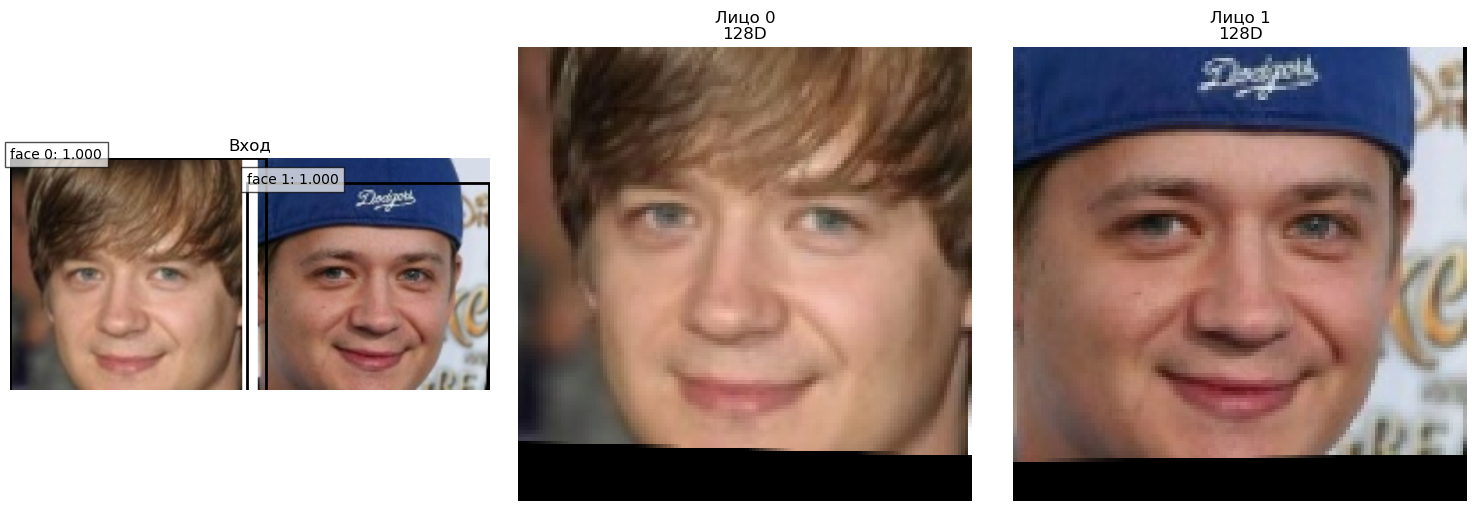

{
  "cosine_similarity": 0.9445369243621826,
  "cosine_distance": 0.05546307563781738,
  "euclidean_distance": 0.33305633068084717
}

Разные люди: [2932, 7206]


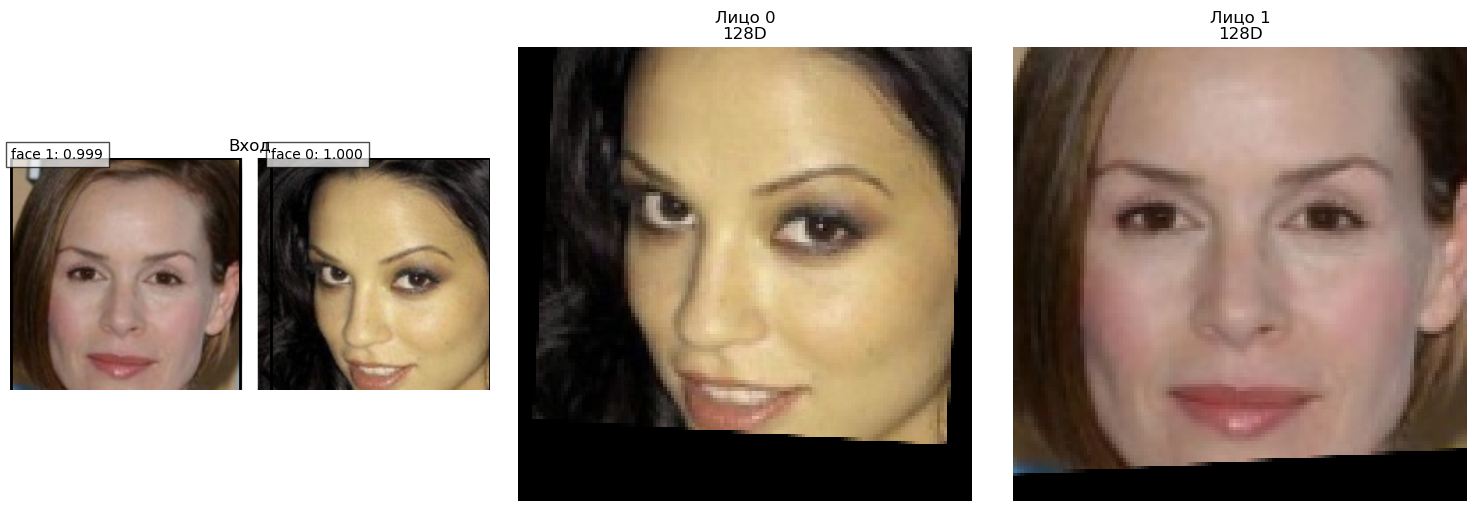

{
  "cosine_similarity": 0.16164399683475494,
  "cosine_distance": 0.8383560031652451,
  "euclidean_distance": 1.2948791980743408
}


In [13]:
def side_by_side(path1, path2, height=300, gap=20):
    """
    Объединяет два изображения в одно горизонтальное полотно.
    """
    images = [
        read_rgb(path1),
        read_rgb(path2)
    ]

    resized_images = []

    for image in images:
        scale = height / image.shape[0]
        new_width = int(image.shape[1] * scale)

        resized = cv2.resize(
            image,
            (new_width, height),
            interpolation=cv2.INTER_LINEAR
        )

        resized_images.append(resized)

    first_image = resized_images[0]
    second_image = resized_images[1]

    canvas_width = (
        first_image.shape[1]
        + gap
        + second_image.shape[1]
    )

    canvas = np.full(
        (height, canvas_width, 3),
        255,
        dtype=np.uint8
    )

    canvas[:, :first_image.shape[1]] = first_image

    second_start = first_image.shape[1] + gap
    canvas[:, second_start:] = second_image

    return canvas


def choose_pairs():
    """
    Выбирает:
    1. Два изображения одного человека.
    2. Два изображения разных людей.
    """
    df = pd.read_csv(GALLERY_CSV)

    df = df.dropna(
        subset=["image_id", "person_id"]
    ).copy()

    df["path"] = df["image_id"].map(
        lambda image_id: str(
            GALLERY_IMAGE_DIR / str(image_id)
        )
    )

    # Оставляем только реально существующие изображения.
    df = df[
        df["path"].map(os.path.exists)
    ].copy()

    if df.empty:
        raise RuntimeError(
            "В галерее не найдено ни одного доступного изображения."
        )

    person_counts = df["person_id"].value_counts()

    people_with_two_images = person_counts[
        person_counts >= 2
    ]

    if people_with_two_images.empty:
        raise RuntimeError(
            "Нет человека минимум с двумя изображениями."
        )

    # Пара одного человека.
    same_person_id = people_with_two_images.index[0]

    same_person_rows = df[
        df["person_id"] == same_person_id
    ].head(2)

    same_paths = same_person_rows["path"].tolist()

    # Пара разных людей.
    different_people_rows = df.drop_duplicates(
        subset=["person_id"]
    ).head(2)

    if len(different_people_rows) < 2:
        raise RuntimeError(
            "Недостаточно разных людей для сравнения."
        )

    different_person_ids = (
        different_people_rows["person_id"].tolist()
    )

    different_paths = (
        different_people_rows["path"].tolist()
    )

    return (
        same_person_id,
        same_paths,
        different_person_ids,
        different_paths
    )


same_pid, same_paths, diff_pids, diff_paths = choose_pairs()

examples = [
    {
        "title": f"Один человек: {same_pid}",
        "canvas": side_by_side(
            same_paths[0],
            same_paths[1]
        )
    },
    {
        "title": f"Разные люди: {diff_pids}",
        "canvas": side_by_side(
            diff_paths[0],
            diff_paths[1]
        )
    }
]

for example in examples:
    title = example["title"]
    canvas = example["canvas"]

    print(f"\n{title}")

    results = process_image(
        canvas,
        visualize=True
    )

    if len(results) >= 2:
        metrics = compare_embeddings(
            results[0]["embedding"],
            results[1]["embedding"]
        )

        print(
            json.dumps(
                metrics,
                indent=2,
                ensure_ascii=False
            )
        )
    else:
        print(
            "Детектор не нашёл оба лица. "
            f"Найдено лиц: {len(results)}"
        )

## 10. Индекс эмбеддингов датасета

In [14]:
class GalleryDataset(Dataset):
    def __init__(self,df): self.df=df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self,i):
        row=self.df.iloc[i]; bgr=cv2.imread(str(GALLERY_IMAGE_DIR/str(row.image_id)))
        rgb=cv2.cvtColor(bgr,cv2.COLOR_BGR2RGB)
        return arc_transform(rgb),str(row.image_id),int(row.person_id)

def build_gallery(limit=GALLERY_LIMIT,batch_size=64):
    df=pd.read_csv(GALLERY_CSV).dropna(subset=["image_id","person_id"])
    df=df[df.image_id.map(lambda x:(GALLERY_IMAGE_DIR/str(x)).exists())]
    if limit is not None: df=df.head(int(limit))
    loader=DataLoader(GalleryDataset(df),batch_size=batch_size,shuffle=False,num_workers=0)
    embeddings=[]; ids=[]; pids=[]
    with torch.inference_mode():
        for images,image_ids,person_ids in tqdm(loader,desc="Галерея"):
            embeddings.append(arcface_model(images.to(DEVICE)).cpu().numpy().astype(np.float32)); ids.extend(image_ids); pids.extend(person_ids.numpy())
    data={"embeddings":np.concatenate(embeddings),"image_ids":np.asarray(ids),"person_ids":np.asarray(pids)}
    GALLERY_INDEX_PATH.parent.mkdir(parents=True,exist_ok=True)
    np.savez_compressed(GALLERY_INDEX_PATH,**data); print("Сохранено:",GALLERY_INDEX_PATH,data["embeddings"].shape); return data

def load_gallery():
    if not GALLERY_INDEX_PATH.exists(): return build_gallery()
    z=np.load(GALLERY_INDEX_PATH,allow_pickle=False)
    return {"embeddings":z["embeddings"].astype(np.float32),"image_ids":z["image_ids"],"person_ids":z["person_ids"]}

gallery=load_gallery()

Галерея:   0%|          | 0/176 [00:00<?, ?it/s]

Сохранено: D:\DownloadsEdge\CelebA-20260711T114423Z-2-001\processed_new\face_recognition_final\gallery_embeddings.npz (11249, 128)


## 11. Поиск ближайшего лица

In [16]:
def nearest_faces(query_embedding, gallery, top_k=5):
    """
    Поиск наиболее похожих лиц по косинусному сходству.
    """

    query_embedding = query_embedding.astype(np.float32)
    query_embedding /= np.linalg.norm(query_embedding) + 1e-12

    gallery_embeddings = gallery["embeddings"].astype(np.float32)
    gallery_embeddings /= (
        np.linalg.norm(gallery_embeddings, axis=1, keepdims=True) + 1e-12
    )

    similarities = gallery_embeddings @ query_embedding

    indices = np.argsort(similarities)[::-1][:top_k]

    rows = []

    for rank, idx in enumerate(indices, start=1):

        rows.append({
            "rank": rank,
            "image_id": str(gallery["image_ids"][idx]),
            "person_id": int(gallery["person_ids"][idx]),
            "cosine_similarity": float(similarities[idx]),
            "cosine_distance": float(1.0 - similarities[idx]),
            "path": str(
                GALLERY_IMAGE_DIR /
                str(gallery["image_ids"][idx])
            )
        })

    return pd.DataFrame(rows)


def find_similar(source, top_k=5):
    """
    Поиск наиболее похожих лиц из галереи.
    """

    query_faces = process_image(source)

    all_results = []

    if len(query_faces) == 0:
        print("Лица на изображении не найдены.")
        return []

    for face_index, query in enumerate(query_faces):

        print(f"\n===== Запрос {face_index + 1} =====")

        table = nearest_faces(
            query["embedding"],
            gallery,
            top_k=top_k
        )

        display(
            table.drop(columns="path")
        )

        all_results.append(table)

        fig, axes = plt.subplots(
            1,
            len(table) + 1,
            figsize=(3 * (len(table) + 1), 3)
        )

        axes = np.atleast_1d(axes)

        # Запрос
        axes[0].imshow(query["aligned_face"])
        axes[0].set_title("Запрос")
        axes[0].axis("off")

        # Найденные лица
        for ax, (_, row) in zip(
            axes[1:],
            table.iterrows()
        ):

            image = read_rgb(row["path"])

            ax.imshow(image)

            ax.set_title(
                f"#{int(row['rank'])}\n"
                f"Person {int(row['person_id'])}\n"
                f"Sim = {row['cosine_similarity']:.3f}"
            )

            ax.axis("off")

        plt.tight_layout()
        plt.show()

    return all_results

## 12. Загрузка собственного изображения кнопкой

In [17]:
import ipywidgets as widgets
from IPython.display import display,clear_output
upload=widgets.FileUpload(accept="image/*",multiple=False,description="Выбрать фото")
button=widgets.Button(description="Найти похожее",button_style="success")
out=widgets.Output()

def uploaded_bytes(value):
    if not value: return None
    if isinstance(value,dict): return next(iter(value.values()))["content"]
    return value[0]["content"]

def run_search(_):
    with out:
        clear_output(); content=uploaded_bytes(upload.value)
        if content is None: print("Сначала выберите изображение"); return
        image=Image.open(io.BytesIO(content)).convert("RGB")
        find_similar(image,top_k=5)
button.on_click(run_search)
display(widgets.VBox([upload,button,out]))

In [18]:
import ipywidgets as widgets
from IPython.display import display,clear_output
upload=widgets.FileUpload(accept="image/*",multiple=False,description="Выбрать фото")
button=widgets.Button(description="Найти похожее",button_style="success")
out=widgets.Output()

def uploaded_bytes(value):
    if not value: return None
    if isinstance(value,dict): return next(iter(value.values()))["content"]
    return value[0]["content"]

def run_search(_):
    with out:
        clear_output(); content=uploaded_bytes(upload.value)
        if content is None: print("Сначала выберите изображение"); return
        image=Image.open(io.BytesIO(content)).convert("RGB")
        find_similar(image,top_k=5)
button.on_click(run_search)
display(widgets.VBox([upload,button,out]))

In [19]:
import ipywidgets as widgets
from IPython.display import display,clear_output
upload=widgets.FileUpload(accept="image/*",multiple=False,description="Выбрать фото")
button=widgets.Button(description="Найти похожее",button_style="success")
out=widgets.Output()

def uploaded_bytes(value):
    if not value: return None
    if isinstance(value,dict): return next(iter(value.values()))["content"]
    return value[0]["content"]

def run_search(_):
    with out:
        clear_output(); content=uploaded_bytes(upload.value)
        if content is None: print("Сначала выберите изображение"); return
        image=Image.open(io.BytesIO(content)).convert("RGB")
        find_similar(image,top_k=5)
button.on_click(run_search)
display(widgets.VBox([upload,button,out]))

## 13. Альтернативный поиск по пути

In [ ]:
MY_IMAGE_PATH=r"D:\path\to\my_photo.jpg"
# results=find_similar(MY_IMAGE_PATH,top_k=5)

## 14. Интерпретация

- Чем выше `cosine_similarity`, тем лица ближе в пространстве эмбеддингов.
- Чем ниже `cosine_distance` и `euclidean_distance`, тем лица похожее.
- Порог совпадения следует подбирать на отдельном наборе положительных и отрицательных пар.
- Если человека нет в галерее, поиск всё равно вернёт математически ближайшее изображение. Это не является доказательством совпадения личности.
